# Desarrollo y obtención de características derivadas

### Importación de Módulos

In [415]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import json
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score
from scipy.sparse import csr_matrix, hstack
import lightgbm as lgb

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

### Carga de datasets

In [416]:
df_cleaned = pd.read_csv("../data/gen9ou_cleaned_no_duplicates.csv")
df_cleaned.head()

,battle_id,p1_poke1,p1_poke2,p1_poke3,p1_poke4,p1_poke5,p1_poke6,p2_poke1,p2_poke2,p2_poke3,p2_poke4,p2_poke5,p2_poke6,p1_win
0,83362-gen9ou-2484742250,Krookodile,Kommo-o,Araquanid,Inteleon,Noivern,Muk-Alola,Alomomola,Slowking-Galar,Corviknight,Garchomp,Hatterene,Dragonite,1
1,gen9ou-2008544089,Ninetales-Alola,Manaphy,Kommo-o,Iron Valiant,Samurott-Hisui,Kingambit,Pawmot,Samurott-Hisui,Toxapex,Walking Wake,Empoleon,Great Tusk,1
2,gen9ou-2032727153,Serperior,Darkrai,Zapdos,Dragapult,Iron Valiant,Kingambit,Cresselia,Garganacl,Blissey,Dondozo,Skarmory,Breloom,1
3,gen9ou-2301833199,Ogerpon-Wellspring,Gholdengo,Glimmora,Raging Bolt,Iron Moth,Dragonite,Pelipper,Talonflame,Barraskewda,Zapdos,Manaphy,Bellibolt,1
4,gen9ou-2346353253,Garchomp,Slowking-Galar,Gholdengo,Moltres,Iron Valiant,Kingambit,Ceruledge,Rillaboom,Hatterene,Great Tusk,Scizor,Hawlucha,1


In [417]:
pokemon_stats_df = pd.read_csv("../data/OUStats.csv")
pokemon_stats_df.head()

,ID,Name,Form,Type1,Type2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation
0,1,Bulbasaur,,Grass,Poison,318,45,49,49,65,65,45,1
1,2,Ivysaur,,Grass,Poison,405,60,62,63,80,80,60,1
2,3,Venusaur,,Grass,Poison,525,80,82,83,100,100,80,1
3,4,Charmander,,Fire,,309,39,52,43,60,50,65,1
4,5,Charmeleon,,Fire,,405,58,64,58,80,65,80,1


## 1. Estadísticas individuales, medias, máximas y mínimas de cada equipo

### 1.1 Estadísticas individuales 

A continuación se ejecutan funciones necesarias para el mapeo de nombres de Pokémon al dataset de estadísticas

In [418]:
import json

with open("../mapping/mapping.json", "r") as f:
    name_mapping = json.load(f)

# Crear diccionarios rápidos
map_target = {k: v["target_name"] for k, v in name_mapping.items()}
map_form = {k: v.get("form", None) for k, v in name_mapping.items()}

In [419]:
import unicodedata

def remove_accents(s):
    if isinstance(s, str):
        return ''.join(
            c for c in unicodedata.normalize('NFD', s)
            if unicodedata.category(c) != 'Mn'
        )
    return s

In [420]:
df = df_cleaned.copy()

p1_cols = [f"p1_poke{i}" for i in range(1, 7)]
p2_cols = [f"p2_poke{i}" for i in range(1, 7)]

all_poke_cols = p1_cols + p2_cols

Mapeo usando **mapping.json**

In [421]:
def apply_mapping(name):
    if name in name_mapping:
        entry = name_mapping[name]
        mapped_name = entry["target_name"]
        
        # decidir forma
        form = entry.get("form", " ")
        if form is None:
            form = " "
            
    else:
        # no está en mapping
        mapped_name = name
        form = " "
    
    return mapped_name, form

In [422]:
for col in all_poke_cols:
    mapped = df[col].apply(apply_mapping)
    
    df[f"{col}"] = mapped.apply(lambda x: x[0])
    df[f"{col}_form"] = mapped.apply(lambda x: x[1])

In [423]:
df.to_csv("../data/gen9ou_cleaned_mapped_dataset.csv", index=False)

Preparación de tabla de stats con optimización y función para obtener stats de cada Pokémon en cada combate

In [424]:
stats_cols = ["Name", "Form", "Type1", "Type2", "HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]

stats_df = pokemon_stats_df[stats_cols].copy()
stats_df = stats_df.rename(columns={
    "Name": "pokemon_name",
    "Form": "form"
})

In [425]:
for col in all_poke_cols:
    df[col]= df[col].apply(remove_accents)

stats_df["pokemon_name"] = stats_df["pokemon_name"].apply(remove_accents)
stats_df["form"] = stats_df["form"].apply(remove_accents)

In [426]:
def add_stats(df, prefix): 
    result = df.copy() 
    for i in range(1, 7): 
        name_col = f"{prefix}_poke{i}" 
        form_col = f"{prefix}_poke{i}_form" 
        temp = stats_df.copy() 
        temp = temp.add_suffix(f"_{prefix}_{i}") 
        
        result = result.merge( 
            temp, left_on=[name_col, form_col], 
            right_on=[f"pokemon_name_{prefix}_{i}", f"form_{prefix}_{i}"], 
            how="left" 
            ) 
        
        result = result.drop(columns=[
            f"pokemon_name_{prefix}_{i}",
            f"form_{prefix}_{i}"
        ])
        
        print(f"Nulos en Merge {prefix}_poke{i}:", result[f"HP_{prefix}_{i}"].isna().mean())
        
    return result

In [427]:
#celda debug para verificar que el merge funciona correctamente
# 1. combinaciones del dataset de combates
all_pairs = []

for col in all_poke_cols:
    temp = df[[f"{col}", f"{col}_form"]].copy()
    temp.columns = ["pokemon_name", "form"]
    all_pairs.append(temp)

all_pairs_df = pd.concat(all_pairs).drop_duplicates()

# 2. combinaciones válidas
valid_pairs = stats_df[["pokemon_name", "form"]].drop_duplicates()

# 3. detectar missing
missing_pairs = all_pairs_df.merge(
    valid_pairs,
    on=["pokemon_name", "form"],
    how="left",
    indicator=True
)

missing_pairs = missing_pairs[missing_pairs["_merge"] == "left_only"]

print("Pokémon sin match:", len(missing_pairs))
print(missing_pairs.head(34))

Pokémon sin match: 0
Empty DataFrame
Columns: [pokemon_name, form, _merge]
Index: []


In [428]:
# =========================
# AUTO MAPEO (FIX DE FORMAS)
# =========================

auto_mapping = []

for _, row in missing_pairs.iterrows():
    name = row["pokemon_name"]
    form = row["form"]
    
    # buscar en stats por nombre
    matches = valid_pairs[valid_pairs["pokemon_name"] == name]
    
    # si hay exactamente una coincidencia → problema de form
    if len(matches) == 1:
        correct_form = matches.iloc[0]["form"]
        
        auto_mapping.append({
            "original_name": name,
            "original_form": form,
            "target_name": name,
            "correct_form": correct_form
        })
    if len(matches) > 1:
        print(f"Advertencia: {name} tiene múltiples formas en stats, no se puede auto-mapear.")
        

auto_mapping_df = pd.DataFrame(auto_mapping)

print("Auto-mapping candidates:", len(auto_mapping_df))
auto_mapping_df.head(20)


Auto-mapping candidates: 0


""


Se guardan todos los candidatos de mapeo automático (nombres que no se encuentran en mapping.json pero que tienen una única coincidencia en stats.csv) directamente en mapping.json para evitar tener que volver a hacer este proceso en el futuro. 

In [429]:
def update_mapping_from_df(auto_mapping_df, mapping_path="../mapping/mapping.json"):
    
    with open(mapping_path, "r") as f:
        name_mapping = json.load(f)
       
    # CONSTRUIR mapping_updates DESDE auto_mapping_df
    mapping_updates = {}

    for _, row in auto_mapping_df.iterrows():
        original = row["original_name"]
        target_name = row["target_name"]
        correct_form = row["correct_form"]
        
        mapping_updates[original] = {
            "target_name": target_name,
            "keep": True,
            "form": correct_form
        }
    
    # AÑADIR SOLO NUEVOS
    new_entries = 0

    for key, value in mapping_updates.items():
        if key not in name_mapping:
            name_mapping[key] = value
            new_entries += 1

    print(f"New mappings added: {new_entries}")
    
    with open(mapping_path, "w") as f:
        json.dump(name_mapping, f, indent=2, ensure_ascii=False)

    print("mapping.json updated successfully")

In [430]:
update_mapping_from_df(auto_mapping_df)

New mappings added: 0
mapping.json updated successfully


In [431]:
df_stats = add_stats(df, "p1")
df_stats = add_stats(df_stats, "p2")

df_stats.to_csv("../data/gen9ou_cleaned_mapped_with_stats.csv", index=False)

print(df_stats.shape, df.shape)

Nulos en Merge p1_poke1: 0.0
Nulos en Merge p1_poke2: 0.0
Nulos en Merge p1_poke3: 0.0
Nulos en Merge p1_poke4: 0.0
Nulos en Merge p1_poke5: 0.0
Nulos en Merge p1_poke6: 0.0
Nulos en Merge p2_poke1: 0.0
Nulos en Merge p2_poke2: 0.0
Nulos en Merge p2_poke3: 0.0
Nulos en Merge p2_poke4: 0.0
Nulos en Merge p2_poke5: 0.0
Nulos en Merge p2_poke6: 0.0
(1761834, 122) (1761834, 26)


In [432]:
dupes = stats_df.duplicated(subset=["pokemon_name", "form"], keep=False)

print("Duplicados en stats_df:", dupes.sum())
print(stats_df[dupes].sort_values(["pokemon_name", "form"]).head(20))

Duplicados en stats_df: 0
Empty DataFrame
Columns: [pokemon_name, form, Type1, Type2, HP, Attack, Defense, Sp. Atk, Sp. Def, Speed]
Index: []


In [433]:
print(df.shape)
print(df_stats.shape)

print(df_stats.isna().sum().sum())

assert len(df) == len(df_stats)


(1761834, 26)
(1761834, 122)
510974


### 1.2 Medias, máximas y mínimas de cada equipo 

Funcion para la obtención de estadísticas medias, máximas y mínimas de cada equipo en cada combate

In [434]:
stat_names = ["HP", "Attack", "Defense", "Sp. Atk", "Sp. Def", "Speed"]

def aggregate_team(df, prefix):
    agg = pd.DataFrame(index=df.index)
    
    for stat in stat_names:
        cols = [f"{stat}_{prefix}_{i}" for i in range(1, 7)]
        
        agg[f"{prefix}_mean_{stat}"] = df[cols].mean(axis=1)
        agg[f"{prefix}_max_{stat}"] = df[cols].max(axis=1)
        agg[f"{prefix}_min_{stat}"] = df[cols].min(axis=1)
    
    return agg

In [435]:
p1_agg = aggregate_team(df_stats, "p1")
p2_agg = aggregate_team(df_stats, "p2")

### 1.3 Diferenciales 

In [436]:
diff_df = p1_agg.values - p2_agg.values
diff_df = pd.DataFrame(diff_df, columns=[f"diff_{col}" for col in p1_agg.columns])

### 1.4 Experimento LightGBM sin tuning con diferenciales 

In [437]:
# concatenar las columnas de all_poke_cols con las de diff_df

X_differentials = pd.concat([df_cleaned[all_poke_cols], diff_df], axis=1)
y = df_cleaned["p1_win"]
diff_df.head()

print(diff_df.shape, df_cleaned.shape)
print(diff_df.index.equals(df_cleaned.index))

stats_df["pokemon_name"].value_counts().head(10)

(1761834, 18) (1761834, 14)
True


pokemon_name
Arceus          9
Tauros          4
Pumpkaboo       4
Gourgeist       4
Oricorio        4
Necrozma        4
Squawkabilly    4
Burmy           3
Calyrex         3
Terapagos       3
Name: count, dtype: int64

Cargado de ids de splits de entrenamiento, validación y test y separación de los datasets correspondientes

In [438]:
train_ids = pd.read_csv("../splits/train_ids.csv")
val_ids = pd.read_csv("../splits/val_ids.csv")
test_ids = pd.read_csv("../splits/test_ids.csv")

train_ids = set(train_ids["battle_id"])
val_ids = set(val_ids["battle_id"])
test_ids = set(test_ids["battle_id"])

#### 1.4.1 Preparación de sparse matrix en formato Team Differential

In [439]:
pokemon_cols = [
    "p1_poke1","p1_poke2","p1_poke3","p1_poke4","p1_poke5","p1_poke6",
    "p2_poke1","p2_poke2","p2_poke3","p2_poke4","p2_poke5","p2_poke6"
]

all_pokemon = pd.unique(df_stats[pokemon_cols].values.ravel())

pokemon_to_idx = {p: i for i, p in enumerate(sorted(all_pokemon))}
n_pokemon = len(pokemon_to_idx)

def build_team_differential(df, pokemon_to_idx):
    n_pokemon = len(pokemon_to_idx)
    
    rows = []
    cols = []
    data = []
    
    y = df['p1_win'].values
    
    for row_idx, row in enumerate(df.itertuples(index=False)):
        # team 1: +1
        for p in [row.p1_poke1,row.p1_poke2,row.p1_poke3,row.p1_poke4,row.p1_poke5,row.p1_poke6]:
            cols.append(pokemon_to_idx[p])
            rows.append(row_idx)
            data.append(1)
        
        # team 2: -1
        for p in [row.p2_poke1,row.p2_poke2,row.p2_poke3,row.p2_poke4,row.p2_poke5,row.p2_poke6]:
            cols.append(pokemon_to_idx[p])
            rows.append(row_idx)
            data.append(-1)
    
    X = csr_matrix((data, (rows, cols)), shape=(len(df), n_pokemon), dtype=np.int8)
    
    return X, y

In [443]:
X_sparse, y = build_team_differential(df, pokemon_to_idx)

In [444]:
train_mask = df["battle_id"].isin(train_ids)
val_mask   = df["battle_id"].isin(val_ids)
test_mask  = df["battle_id"].isin(test_ids)

train_mask = df["battle_id"].isin(train_ids).values
val_mask   = df["battle_id"].isin(val_ids).values
test_mask  = df["battle_id"].isin(test_ids).values


X_train_sparse = X_sparse[train_mask]
X_val_sparse   = X_sparse[val_mask]
X_test_sparse  = X_sparse[test_mask]

y_train = y[train_mask]
y_val   = y[val_mask]
y_test  = y[test_mask]

Se obtienen las matrices dispersas para cada split

In [445]:
X_stats = diff_df.astype(np.float32)

X_train_stats = X_stats.iloc[train_mask]
X_val_stats = X_stats.iloc[val_mask]
X_test_stats = X_stats.iloc[test_mask]

# comprobacion de que Xtrain_stats, X_val_stats y X_test_stats tienen el mismo orden que X_train_sparse, X_val_sparse y X_test_sparse
assert X_train_stats.index.equals(df_cleaned[train_mask].index)
assert X_val_stats.index.equals(df_cleaned[val_mask].index)
assert X_test_stats.index.equals(df_cleaned[test_mask].index)

Se separan las diferenciales por split, se convierten a sparse matrix y se concatenan con las columnas de Pokémon para cada split

In [446]:
X_train_stats_sparse = csr_matrix(X_train_stats.values)
X_val_stats_sparse = csr_matrix(X_val_stats.values)
X_test_stats_sparse = csr_matrix(X_test_stats.values)

In [447]:
X_train = hstack([X_train_sparse, X_train_stats_sparse]).tocsr()
X_val = hstack([X_val_sparse, X_val_stats_sparse]).tocsr()
X_test = hstack([X_test_sparse, X_test_stats_sparse]).tocsr()

In [448]:
print(X_train.nnz)  # número de valores NO cero
print(X_train.shape)

print(diff_df.isna().sum().sum())
print(np.unique(y_train, return_counts=True))


problem_pokemon = set()

for col in all_poke_cols:
    mapped_col = f"{col}_mapped"
    form_col = f"{col}_form_final"
    
    missing_mask = df_stats.filter(like=f"{col.split('_')[0]}").isna().any(axis=1)
    
    problem_pokemon.update(df.loc[missing_mask, col].unique())

print("Pokémon problemáticos:", len(problem_pokemon))
print(list(problem_pokemon)[:50])

31932401
(1127573, 807)
0
(array([0, 1]), array([562636, 564937]))
Pokémon problemáticos: 643
['Feraligatr', 'Nosepass', 'Hawlucha', 'Salazzle', 'KeldeoResolute', 'Cottonee', 'DudunsparceTwo-Segment', 'Zoroark', 'Cyclizar', 'Raging Bolt', 'Electabuzz', 'Rampardos', 'Shroodle', 'Mamoswine', 'Trevenant', 'Grookey', 'Eiscue', 'Delibird', 'Meganium', 'Chien-Pao', 'Marshtomp', 'Dolliv', 'Iron Hands', 'Kricketune', 'Shelgon', 'Glaceon', 'Duosion', 'Foongus', 'Rowlet', 'Gligar', 'Luxray', 'Tsareena', 'Toedscool', 'Zorua-Hisui', 'Toxapex', 'Floragato', 'Tentacruel', 'Cobalion', 'Ogerpon-Hearthflame', 'Zekrom', 'Emboar', 'Ogerpon-Wellspring', 'Trapinch', 'Chi-Yu', 'Charjabug', 'Archaludon', 'Rotom-Fan', 'Darkrai', 'Zoroark-Hisui', 'Seviper']


#### 1.4.2 Entrenamiento y evaluación del modelo LightGBM sin tuning con diferenciales

In [449]:
model = lgb.LGBMClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    n_jobs=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="auc",
    callbacks=[lgb.early_stopping(50)],
)

[LightGBM] [Info] Number of positive: 564937, number of negative: 562636
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.577551 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5508
[LightGBM] [Info] Number of data points in the train set: 1127573, number of used features: 673
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.501020 -> initscore=0.004081
[LightGBM] [Info] Start training from score 0.004081
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[999]	valid_0's auc: 0.566083	valid_0's binary_logloss: 0.685759


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [450]:
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = (y_pred_proba > 0.5).astype(int)

print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Macro:", f1_score(y_test, y_pred, average="macro"))

ROC-AUC: 0.5690305072187782
Accuracy: 0.547457622308559
F1 Macro: 0.5474284299165796


Text(0.5, 1.0, 'Top 30 Feature Importances')

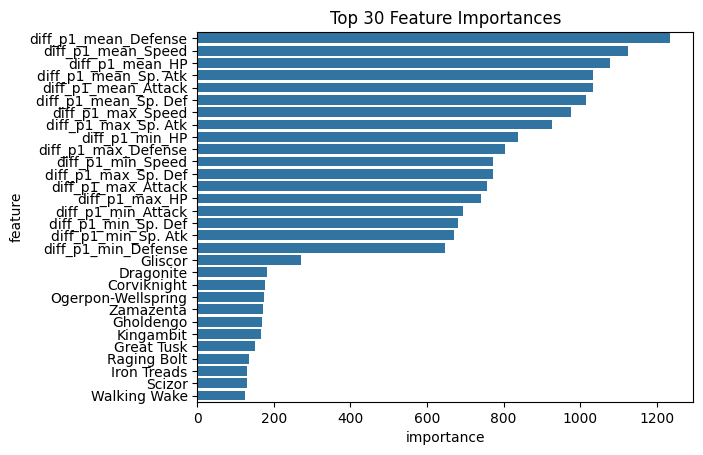

In [453]:
# Sacar el diagrama de barras de las importancias de las features de lightgbm
importances = model.feature_importances_
idx_to_pokemon = {v: k for k, v in pokemon_to_idx.items()}
sparse_feature_names = [idx_to_pokemon[i] for i in range(len(idx_to_pokemon))]
feature_names = sparse_feature_names + list(X_train_stats.columns)
feature_importances = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
})
##ordenar por importancia
feature_importances = feature_importances.sort_values("importance", ascending=False)
sns.barplot(
    x="importance",
    y="feature",
    data=feature_importances.head(30)
)
plt.title("Top 30 Feature Importances")



In [454]:
for f, imp in zip(feature_names, importances):
    if "diff" in f:
        print(f, imp)

diff_p1_mean_HP 1079
diff_p1_max_HP 741
diff_p1_min_HP 837
diff_p1_mean_Attack 1033
diff_p1_max_Attack 757
diff_p1_min_Attack 695
diff_p1_mean_Defense 1234
diff_p1_max_Defense 803
diff_p1_min_Defense 646
diff_p1_mean_Sp. Atk 1033
diff_p1_max_Sp. Atk 926
diff_p1_min_Sp. Atk 671
diff_p1_mean_Sp. Def 1015
diff_p1_max_Sp. Def 772
diff_p1_min_Sp. Def 681
diff_p1_mean_Speed 1125
diff_p1_max_Speed 976
diff_p1_min_Speed 772


In [ ]:
#cuenta los NaN en diff_df
print(diff_df.isna().sum().sum())

63425340
